# MAGIKS classification ablation and BNS/NSBH confusion matrices

**Objective.** Reproduce the four-model classification summary and regenerate the row-normalized BNS/NSBH confusion matrices from the authoritative experiment directories under `Model/eval_results/cls_test`.

The confusion matrices use the full MAGIKS experiment. All reported metrics use the fixed classification threshold stored in each `eval_results.json`.

In [1]:
import json
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    configured = os.environ.get("MAGIKS_REPO_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if (candidate / "Model/eval_results/cls_test").is_dir():
            return candidate
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "Model/eval_results/cls_test").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the gw-kn-multimodal repository root")


REPO_ROOT = find_repo_root()
WORKSPACE_ROOT = REPO_ROOT.parent
RESULT_ROOT = REPO_ROOT / "Model/eval_results/cls_test"
MODEL_DIRS = {
    "MAGIKS": "bns_nsbh_test_full",
    "w/o classification loss": "bns_nsbh_test_no_cls_loss",
    "w/o cross-attention": "bns_nsbh_test_no_cross_atten",
    "w/o fusion": "bns_nsbh_test_no_fusion",
}
MODEL_FIGURE = REPO_ROOT / "figures/test_results/confusion_matrix_bns_nsbh.pdf"
PAPER_FIGURE = WORKSPACE_ROOT / "paper_apj/figures/results/cls_test/confusion_matrix_bns_nsbh.pdf"
SOURCE_LOGIT_FIGURE = RESULT_ROOT / MODEL_DIRS["MAGIKS"] / "logits_distribution_triplet.pdf"
PAPER_LOGIT_FIGURE = WORKSPACE_ROOT / "paper_apj/figures/results/cls_test/logits_distribution_triplet.pdf"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print(f"Repository: {REPO_ROOT}")
print(f"Result root: {RESULT_ROOT}")

Repository: /fred/oz016/bgao_kn/gw-kn-multimodal
Result root: /fred/oz016/bgao_kn/gw-kn-multimodal/Model/eval_results/cls_test


## Load and validate the four classification experiments

The comparison uses the aggregate `classification` metrics from each subdirectory. The confusion matrices use `classification_by_source` from the full MAGIKS result.

In [2]:
results = {}
rows = []
for display_name, directory_name in MODEL_DIRS.items():
    result_path = RESULT_ROOT / directory_name / "eval_results.json"
    if not result_path.is_file():
        raise FileNotFoundError(result_path)
    with result_path.open() as handle:
        payload = json.load(handle)
    results[display_name] = payload
    metrics = payload["classification"]
    total = metrics["tp"] + metrics["fp"] + metrics["tn"] + metrics["fn"]
    if total <= 0 or metrics.get("n_dropped_nonfinite", 0) != 0:
        raise ValueError(f"Invalid classification counts in {result_path}")
    rows.append({
        "Method": display_name,
        "AUROC": metrics["auroc"],
        "AUPRC": metrics["auprc"],
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "N pairs": total,
        "Source file": str(result_path.relative_to(REPO_ROOT)),
    })

comparison = pd.DataFrame(rows).set_index("Method")
metric_columns = ["AUROC", "AUPRC", "Accuracy", "Precision", "Recall", "F1"]
if not np.isfinite(comparison[metric_columns].to_numpy()).all():
    raise ValueError("Non-finite values found in the classification summary")
comparison[metric_columns + ["N pairs"]].round(3)

,AUROC,AUPRC,Accuracy,Precision,Recall,F1,N pairs
Method,,,,,,,
MAGIKS,0.987,0.961,0.943,0.855,0.928,0.890,40960
w/o classification loss,0.933,0.819,0.855,0.837,0.520,0.641,40960
w/o cross-attention,0.981,0.945,0.933,0.821,0.937,0.875,40960
w/o fusion,0.552,0.293,0.700,0.332,0.196,0.247,40960


## Row-normalized confusion matrices

Rows are true labels and columns are predicted labels. Each row is normalized independently, so the diagonal entries give the true-negative and true-positive rates for each source population.

In [3]:
source_labels = {"bns": "BNS", "nsbh": "NSBH"}
full_result = results["MAGIKS"]
matrices = {}
summary_rows = []

for source, source_label in source_labels.items():
    metrics = full_result["classification_by_source"][source]["metrics"]
    raw = np.array([
        [metrics["tn"], metrics["fp"]],
        [metrics["fn"], metrics["tp"]],
    ], dtype=float)
    row_totals = raw.sum(axis=1, keepdims=True)
    if np.any(row_totals == 0):
        raise ValueError(f"Empty confusion-matrix row for {source}")
    normalized = raw / row_totals
    if not np.allclose(normalized.sum(axis=1), 1.0):
        raise AssertionError(f"Rows do not sum to one for {source}")
    matrices[source] = normalized
    for true_label in (0, 1):
        for predicted_label in (0, 1):
            summary_rows.append({
                "Source": source_label,
                "True label": true_label,
                "Predicted label": predicted_label,
                "Count": int(raw[true_label, predicted_label]),
                "Row fraction": normalized[true_label, predicted_label],
            })

matrix_summary = pd.DataFrame(summary_rows)
matrix_summary

,Source,True label,Predicted label,Count,Row fraction
0,BNS,0,0,15383,0.948514
1,BNS,0,1,835,0.051486
2,BNS,1,0,344,0.063964
3,BNS,1,1,5034,0.936036
4,NSBH,0,0,13721,0.946145
5,NSBH,0,1,781,0.053855
6,NSBH,1,0,389,0.080008
7,NSBH,1,1,4473,0.919992


Saved: /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_bns_nsbh.pdf
Copied: /fred/oz016/bgao_kn/paper_apj/figures/results/cls_test/confusion_matrix_bns_nsbh.pdf
Copied: /fred/oz016/bgao_kn/paper_apj/figures/results/cls_test/logits_distribution_triplet.pdf


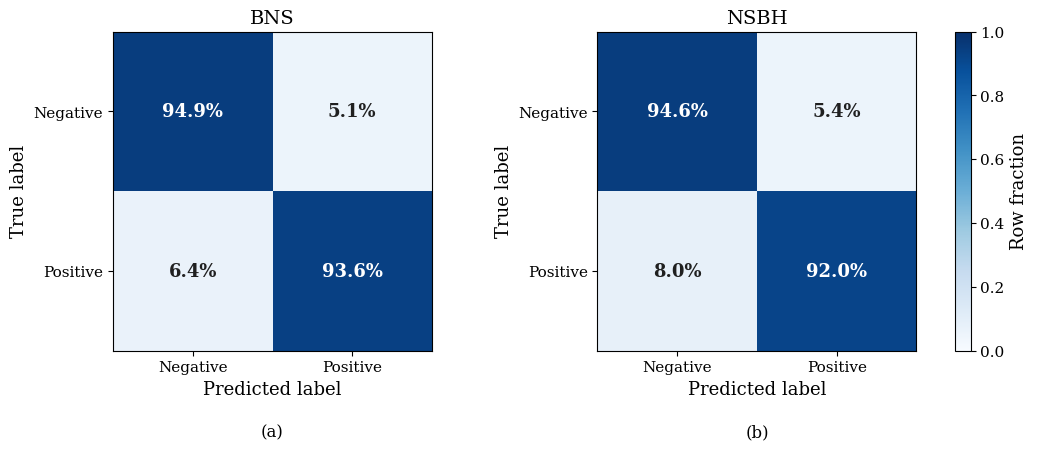

In [4]:
labels = ["Negative", "Positive"]
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4), constrained_layout=True)
image = None

for panel_index, (ax, (source, source_label)) in enumerate(zip(axes, source_labels.items())):
    matrix = matrices[source]
    image = ax.imshow(matrix, cmap="Blues", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_title(source_label)
    ax.set_xticks([0, 1], labels=labels)
    ax.set_yticks([0, 1], labels=labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    for row in range(2):
        for column in range(2):
            value = matrix[row, column]
            ax.text(
                column,
                row,
                f"{value:.1%}",
                ha="center",
                va="center",
                color="white" if value >= 0.5 else "#202020",
                fontsize=13,
                fontweight="bold",
            )
    ax.text(0.5, -0.23, f"({chr(ord('a') + panel_index)})", transform=ax.transAxes,
            ha="center", va="top", fontsize=12, clip_on=False)

colorbar = fig.colorbar(image, ax=axes, fraction=0.04, pad=0.04)
colorbar.set_label("Row fraction")
colorbar.set_ticks(np.linspace(0, 1, 6))

MODEL_FIGURE.parent.mkdir(parents=True, exist_ok=True)
PAPER_FIGURE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    MODEL_FIGURE,
    dpi=300,
    bbox_inches="tight",
    metadata={
        "Title": "MAGIKS BNS and NSBH classification confusion matrices",
        "Subject": "Row-normalized fixed-threshold classification results",
    },
)
shutil.copyfile(MODEL_FIGURE, PAPER_FIGURE)
if not SOURCE_LOGIT_FIGURE.is_file():
    raise FileNotFoundError(SOURCE_LOGIT_FIGURE)
shutil.copyfile(SOURCE_LOGIT_FIGURE, PAPER_LOGIT_FIGURE)
print(f"Saved: {MODEL_FIGURE}")
print(f"Copied: {PAPER_FIGURE}")
print(f"Copied: {PAPER_LOGIT_FIGURE}")

plt.show()

## Result note

The figure and the classification summary above are derived from the same four experiment directories. Re-running the notebook refreshes both manuscript and model-repository copies of the confusion-matrix PDF.